# 활성화 함수

| 활성화 함수          | 수식 또는 정의                                                                                   | 출력 범위       | 미분 가능성        | 비선형성 | 주요 특징 및 장점                          | 단점 또는 주의점                                   |
| --------------- | ------------------------------------------------------------------------------------------ | ----------- | ------------- | ---- | ----------------------------------- | ------------------------------------------- |
| **Binary Step** | $f(x) = \begin{cases} 1 & x \geq 0 \\ 0 & x < 0 \end{cases}$                               | {0, 1}      | X (x=0에서 불연속) | X    | 단순 이진 분류용. 퍼셉트론에 사용.                | 미분 불가능 → 역전파 불가                             |
| **Sigmoid**     | $f(x) = \frac{1}{1 + e^{-x}}$                                                              | (0, 1)      | O             | O    | 확률로 해석 가능. 출력이 부드럽고 연속적.            | 기울기 소실(Vanishing Gradient) 문제. 출력 중심이 0이 아님 |
| **Tanh**        | $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$                                                 | (-1, 1)     | O             | O   | 중심이 0 → sigmoid보다 학습 수렴 빠름          | 기울기 소실 존재 (sigmoid보다 덜하지만 여전히 있음)           |
| **ReLU**        | $f(x) = \max(0, x)$                                                                        | \[0, ∞)     | O             | O    | 계산 간단, 빠른 수렴. 현재 가장 널리 사용           | 음수 입력은 0 출력 → **죽은 ReLU** 문제                |
| **Leaky ReLU**  | $f(x) = \begin{cases} x & x > 0 \\ \alpha x & x \leq 0 \end{cases}$ <br>(보통 $\alpha=0.01$) | (-∞, ∞)     | O             | O   | 죽은 ReLU 문제 해결. 음수 영역에도 작은 기울기 존재    | $\alpha$ 값 튜닝 필요                            |
| **ELU**         | $f(x) = \begin{cases} x & x > 0 \\ \alpha(e^x - 1) & x \leq 0 \end{cases}$                 | (-α, ∞)     | O             | O    | LeakyReLU보다 더 부드럽고 중심이 0에 가까움       | 지수 계산 → 계산 비용 증가                            |
| **Softmax**     | $f(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}}$                                                | (0, 1), 합=1 | O             | O   | 다중 클래스 분류의 출력층. 각 클래스에 대한 확률로 해석 가능 | 다중 클래스 전용, 은닉층엔 잘 안 씀                       |
| **Gaussian**    | $f(x) = e^{-x^2}$                                                                          | (0, 1]      | O             | O    | RBF 신경망 등에서 사용. 입력의 중심성 반영 가능       | 중심 근처만 활성화 → 표현력 제한적                        |


| 용도             | 추천 활성화 함수              |
| -------------- | ---------------------- |
| 이진 분류          | Sigmoid (출력층)          |
| 다중 클래스 분류      | Softmax (출력층)          |
| 일반적인 은닉층       | ReLU / LeakyReLU / ELU |
| RBF 신경망 등 특수용도 | Gaussian               |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sklearn
import platform
print(platform.system())
if platform.system()== 'Windows':
   sklearn.set_config(display='text')

Windows


In [3]:

import matplotlib.pyplot as plt

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

##  Binary Step

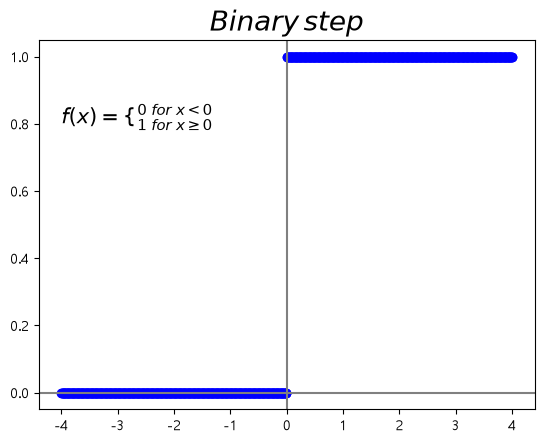

In [4]:
x = np.linspace(start=-4, stop=4, num=1000)
y = [1 if data>=0 else 0 for data in x]

plt.plot(x, y, 'o', c='blue')
plt.axvline(0, c='grey')
plt.axhline(0, c='grey')
plt.title(r'$Binary\/step$', fontsize=20)
plt.text(-4, 0.8, r'$f(x)=\{ \genfrac{}{}{0}{}{0 \/\/ for \/\/ x<0}{1 \/\/ for \/\/ x \geq 0 }$', fontsize=15)
plt.show()



# sigmoid



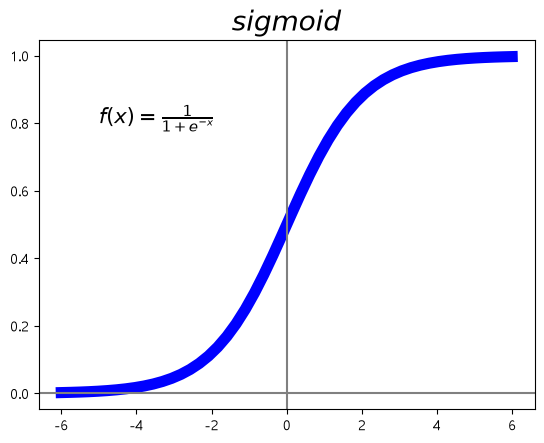

In [6]:
x = np.linspace(start=-6, stop=6, num=50)
y = 1/(1+np.exp(-x))

plt.plot(x, y, c="blue", lw=8)
plt.axvline(0, c="grey")
plt.axhline(0, c="grey")
plt.title(r"$sigmoid$", fontsize=20)
plt.text(-5, 0.8, r"$f(x)=\frac{1}{1+e^{-x}}$", fontsize=15)
plt.show()

## tanh

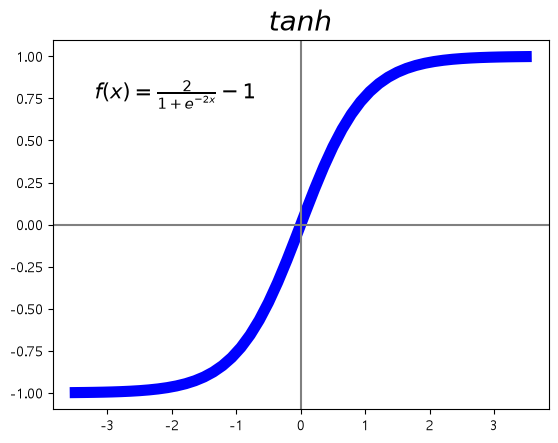

In [7]:
x = np.linspace(start=-3.5, stop=3.5, num=50)
y = np.tanh(x)

plt.plot(x, y, c="blue", lw=8)
plt.axvline(0, c="grey")
plt.axhline(0, c="grey")
plt.title(r"$tanh$", fontsize=20)
plt.text(-3.2, 0.75, r"$f(x)=\frac{2}{1+e^{-2x}}-1$", fontsize=15)
plt.show()

## softmax

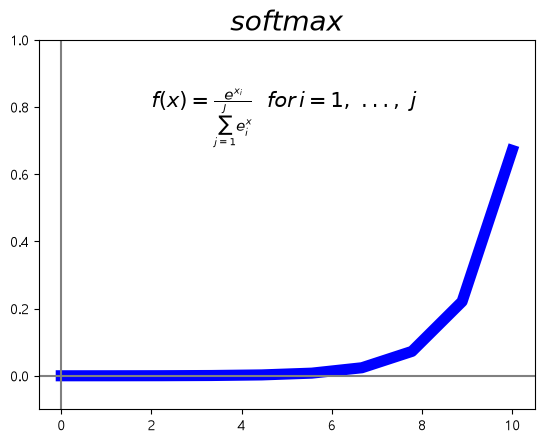

In [8]:
x = np.linspace(start=0, stop=10, num=10)

def softmax(input):
    return np.exp(input) / (np.sum(np.exp(input)))

y = softmax(x)

plt.plot(x, y, c="blue", lw=8)
plt.ylim(-0.1, 1)
plt.axvline(0, c="grey")
plt.axhline(0, c="grey")
plt.title(r"$softmax$", fontsize=20)
plt.text(2, 0.8,
         r"$f(x)=\frac{e^{x_i}}{\sum_{j=1}^J e^x_i}\/\/ \/\/ for\/ i=1,\/\/...,\/\/j$",
         fontsize=15)
plt.show()

## ReLU

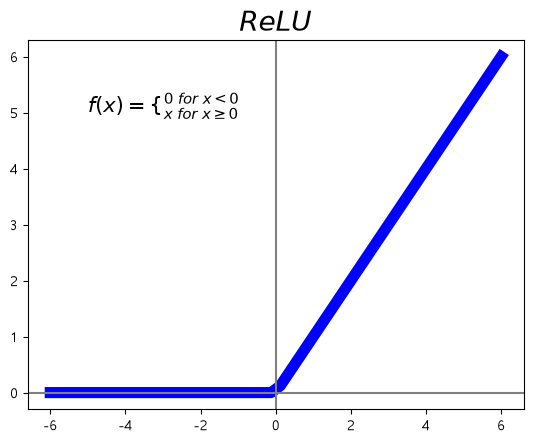

In [9]:
x = np.linspace(start=-6, stop=6, num=50)
y = [ data if data>=0 else 0 for data in x]

plt.plot(x, y, c="blue", lw=8)
plt.axvline(0, c="grey")
plt.axhline(0, c="grey")
plt.title(r"$ReLU$", fontsize=20)
plt.text(-5, 5, r"$f(x)=\{ \genfrac{}{}{0}{}{0 \/\/ for \/\/ x<0}{x \/\/ for \/\/ x\geq0 } $",
         fontsize=15)
plt.show()

## Gaussian

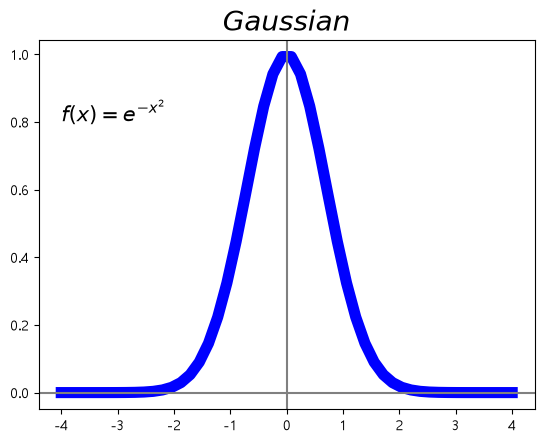

In [10]:
x = np.linspace(start=-4, stop=4, num=50)
y = np.exp(-(x**2))

plt.plot(x, y, c="blue", lw=8)
# plt.ylim(-0.5,2)
plt.axvline(0, c="grey")
plt.axhline(0, c="grey")
plt.title(r"$Gaussian$", fontsize=20)
plt.text(-4, 0.8, r"$f(x)=e^{-x^2 }$", fontsize=15)
plt.show()

## LeakyReLU

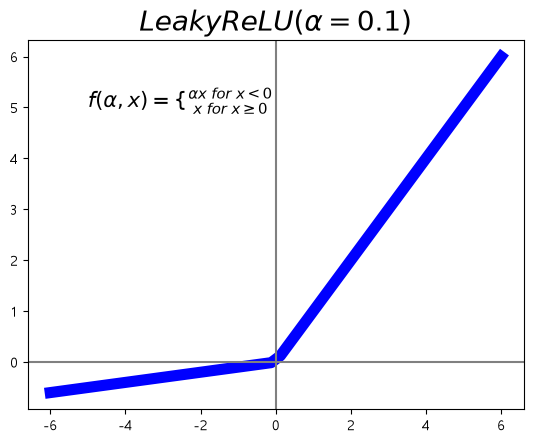

In [11]:
x = np.linspace(start=-6, stop=6, num=50)
y = [ data if data>=0 else 0.1*data for data in x]

plt.plot(x, y, c="blue", lw=8)
plt.axvline(0, c="grey")
plt.axhline(0, c="grey")
plt.title(r"$LeakyReLU(\alpha=0.1)$", fontsize=20)
plt.text(-5, 5,
         r"$f(\alpha,x)=\{ \genfrac{}{}{0}{}{\alpha x \/\/ for \/\/ x<0}{x \/\/ for \/\/ x \geq 0 }$",
         fontsize=15)
plt.show()

## ELU

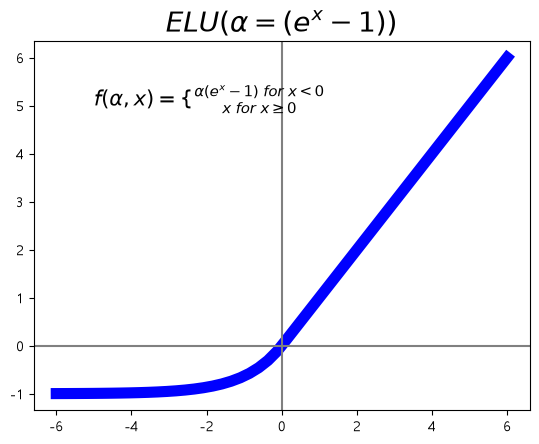

In [12]:
x = np.linspace(start=-6, stop=6, num=50)
y = [ data if data>=0 else 1*(np.e**data-1) for data in x]

plt.plot(x, y, c="blue", lw=8)
plt.axvline(0, c="grey")
plt.axhline(0, c="grey")
plt.title(r"$ELU(\alpha=(e^x -1))$", fontsize=20)
plt.text(-5, 5,
         r"$f(\alpha,x)=\{\genfrac{}{}{0}{}{\alpha (e^x -1) \/\/ for \/\/ x<0}{x \/\/ for \/\/ x \geq 0 }$",
         fontsize=15)
plt.show()

## Pytorch에서 활성화 함수 사용

제공해주신 텐서플로우(Keras) 코드는 다양한 방식(문자열, 객체 변수, 활성화 함수 자체)으로 레이어의 활성화 함수를 지정하는 예시입니다.
파이토치(PyTorch)는 레이어와 활성화 함수를 모두 하나의 독립된 객체(Module)로 취급하여 순서대로 쌓는 구조를 가집니다.

## 💡 텐서플로우와 파이토치 코드 변환 포인트 핵심 요약

   1. 입력 크기(Shape) 명시 필요:
   * 텐서플로우는 Input(shape=(4,)) 지동 지정 후 다음 레이어부터 출력 뉴런 수만 적으면 연결 크기를 알아서 계산합니다.
      * 반면 파이토치는 nn.Linear(in_features, out_features) 선언 시 앞 층의 출력 크기와 뒷 층의 입력 크기를 사람이 직접 똑같이 맞춰서 적어주어야 합니다.
   2. 활성화 함수의 객체화:
   * 파이토치에서는 모든 활성화 함수가 nn.Module을 상속받은 객체(nn.Sigmoid(), nn.PReLU(), nn.ELU())이므로, nn.Sequential 안에 레이어와 동등한 위치로 차례대로 배치해야 합니다.
   3. Softmax의 차원(dim) 설정:
   * 파이토치의 nn.Softmax는 어느 축을 기준으로 총합 100%를 만들지 dim 인자를 필수로 요구합니다. 일반적인 분류 문제의 미니배치 행렬 연산에서는 가장 마지막 차원인 dim=-1을 지정하는 것이 표준입니다.
   

In [17]:
import torch
import torch.nn as nn

# 1. 텐서플로우의 Sequential과 매핑되는 nn.Sequential 모델 생성
model = nn.Sequential(
    # [1층] 입력(4) -> 출력(50) + Sigmoid (Keras의 activation="sigmoid" 대응)
    nn.Linear(4, 50),
    nn.Sigmoid(),
    
    # [2층] 입력(50) -> 출력(50) + PReLU (Keras의 activation=PReLU() 대응)
    nn.Linear(50, 50),
    nn.PReLU(),
    
    # [3층] 입력(50) -> 출력(30) + ELU (Keras의 activation=ELU(alpha=1) 대응)
    nn.Linear(30, 50), # Keras Dense의 입력 크기는 이전 층의 출력 크기(50)를 자동으로 따라갑니다.
    nn.ELU(alpha=1.0),
    
    # [4층] 입력(30) -> 출력(3) + Softmax (Keras의 activation=softmax 대응)
    nn.Linear(50, 3),  # 이전 층의 출력 크기(30)를 입력으로 받음
    nn.Softmax(dim=-1) # dim=-1은 가장 마지막 차원(클래스 차원)을 기준으로 확률을 계산하라는 의미입니다.
)

# 2.  파이토치 모델 아키텍처 인쇄
print(model)


Sequential(
  (0): Linear(in_features=4, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=50, bias=True)
  (3): PReLU(num_parameters=1)
  (4): Linear(in_features=30, out_features=50, bias=True)
  (5): ELU(alpha=1.0)
  (6): Linear(in_features=50, out_features=3, bias=True)
  (7): Softmax(dim=-1)
)


---

모델의 레이어 구조, 출력 형태(Output Shape), 그리고 파라미터(가중치) 개수를 일목요연하게 보여주는 2가지 방법
- 방법 1: 가장 추천하는 방법 (torchsummary 라이브러리 사용)
- 방법 2: 순수 파이토치 코드로 파라미터 수 계산하기

방법 1: 가장 추천하는 방법 (torchsummary 라이브러리 사용)
- 외부 라이브러리인 torchsummary를 사용하면 텐서플로우(model.summary())와 거의 100% 일치하는 레이어별 요약 표를 얻을 수 있습니다. 

In [ ]:
# uv add torchsummary

In [ ]:
# 터미널이나 주피터 노트북에서 먼저 설치해 주세요.
# !pip install torchsummary

import torch
import torch.nn as nn
import torch.nn.init as init
from torchsummary import summary

# 앞서 작성한 파이토치 모델 정의
model = nn.Sequential(
    nn.Linear(4, 50),
    nn.Sigmoid(),
    nn.Linear(50, 50),
    nn.Sigmoid(),
    nn.Linear(50, 30),
    nn.Sigmoid(),
    nn.Linear(30, 3),
    nn.Softmax(dim=-1)
)

# [핵심] model과 함께 데이터의 입력 크기(input_size=(최종 차원 크기,))를 인자로 넣어줍니다.
summary(model, input_size=(4,)) # feature 개수 -> (-1, 4) 형태로 모델 연산 시작 ?

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 50]             250
           Sigmoid-2                   [-1, 50]               0
            Linear-3                   [-1, 50]           2,550
           Sigmoid-4                   [-1, 50]               0
            Linear-5                   [-1, 30]           1,530
           Sigmoid-6                   [-1, 30]               0
            Linear-7                    [-1, 3]              93
           Softmax-8                    [-1, 3]               0
Total params: 4,423
Trainable params: 4,423
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02
----------------------------------------------------------------


방법 2: 순수 파이토치 코드로 파라미터 수 계산하기  
- 별도의 외부 라이브러리를 설치할 수 없는 환경이라면, 아래와 같이 간단한 파이썬 코드를 작성하여 학습 가능한 총 파라미터(가중치 + 편향)의 개수를 직접 계산할 수 있습니다.

In [14]:
# 1. 단순 모델 구조 인쇄 (레이어 이름과 연결 관계 확인)
print("--- [모델 아키텍처] ---")
print(model)

# 2. 총 파라미터(가중치) 개수 계산 및 출력
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n--- [파라미터 요약] ---")
print(f"학습 가능한 총 파라미터 수: {trainable_params:,}개")

--- [모델 아키텍처] ---
Sequential(
  (0): Linear(in_features=4, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=50, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=50, out_features=30, bias=True)
  (5): Sigmoid()
  (6): Linear(in_features=30, out_features=3, bias=True)
  (7): Softmax(dim=-1)
)

--- [파라미터 요약] ---
학습 가능한 총 파라미터 수: 4,423개


아래 코드는 다양한 방식(문자열, 객체 변수, 활성화 함수 자체)으로 레이어의 활성화 함수를 지정하는 예시입니다.
파이토치(PyTorch)는 레이어와 활성화 함수를 모두 하나의 독립된 객체(Module)로 취급하여 순서대로 쌓는 구조를 가집니다. 


## 💡 텐서플로우와 파이토치 코드 포인트 핵심 요약

   1. 입력 크기(Shape) 명시 필요:
   * 텐서플로우는 Input(shape=(4,)) 지동 지정 후 다음 레이어부터 출력 뉴런 수만 적으면 연결 크기를 알아서 계산합니다.
      * 반면 파이토치는 nn.Linear(in_features, out_features) 선언 시 앞 층의 출력 크기와 뒷 층의 입력 크기를 사람이 직접 똑같이 맞춰서 적어주어야 합니다.
   2. 활성화 함수의 객체화:
   * 파이토치에서는 모든 활성화 함수가 nn.Module을 상속받은 객체(nn.Sigmoid(), nn.PReLU(), nn.ELU())이므로, nn.Sequential 안에 레이어와 동등한 위치로 차례대로 배치해야 합니다.
   3. Softmax의 차원(dim) 설정:
   * 파이토치의 nn.Softmax는 어느 축을 기준으로 총합 100%를 만들지 dim 인자를 필수로 요구합니다. 일반적인 분류 문제의 미니배치 행렬 연산에서는 가장 마지막 차원인 dim=-1을 지정하는 것이 표준입니다.

In [15]:
import torch
import torch.nn as nn
import torch.nn.init as init

# 1. 아키텍처 레이어 구성 (가중치 초기화 전 기본 형태 정의)
model = nn.Sequential(
    # [1층] 입력(4) -> 출력(50) + Sigmoid
    nn.Linear(4, 50),
    nn.Sigmoid(),
    
    # [2층] 입력(50) -> 출력(50) + Sigmoid
    nn.Linear(50, 50),
    nn.Sigmoid(),
    
    # [3층] 입력(50) -> 출력(30) + Sigmoid
    nn.Linear(50, 30),
    nn.Sigmoid(),
    
    # [4층] 출력층: 입력(30) -> 출력(3) + Softmax
    nn.Linear(30, 3),
    nn.Softmax(dim=-1)
)

# 2. 파이토치 스타일의 가중치 초기화 (Weight Initialization) 적용
# 인덱스를 통해 Sequential 내부의 nn.Linear 레이어만 콕 집어서 초기화합니다.
with torch.no_grad():
    # [1층 - nn.Linear는 0번째 인덱스] he_normal (Kaiming Normal) 적용
    init.kaiming_normal_(model[0].weight, nonlinearity='sigmoid')
    
    # [2층 - nn.Linear는 2번째 인덱스] glorot_uniform (Xavier Uniform) 적용
    init.xavier_uniform_(model[2].weight)
    
    # [3층 - nn.Linear는 4번째 인덱스] RandomNormal(평균 0, 표준편차 0.1) 적용
    init.normal_(model[4].weight, mean=0.0, std=0.1)
    
    # [4층 - nn.Linear는 6번째 인덱스] 텐서플로우 Dense의 기본값인 glorot_uniform 적용
    init.xavier_uniform_(model[6].weight)

# 3. 모델 아키텍처 및 초기화 결과 확인을 위한 출력
print(model)

Sequential(
  (0): Linear(in_features=4, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=50, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=50, out_features=30, bias=True)
  (5): Sigmoid()
  (6): Linear(in_features=30, out_features=3, bias=True)
  (7): Softmax(dim=-1)
)


---

 2차원 이미지 데이터(28x28)를 1차원으로 펼치고(Flatten), Dense 레이어 사이에 배치 정규화(BatchNormalization)를 적용하는 구조입니다.
파이토치(PyTorch)로  nn.Flatten, nn.Linear, nn.BatchNorm1d를 순서대로 쌓아 구현할 수 있습니다. 

## 💡 파이토치 구조적  포인트  요약

   1. nn.Flatten()의 기본 동작:
   * 파이토치의 nn.Flatten()은 데이터를 1차원으로 쫙 펼쳐주는 역할을 수행합니다. 데이터의 배치를 제외한 나머지 차원(28, 28)을 전부 곱해 784차원의 벡터로 만듭니다.
   2. nn.BatchNorm1d (배치 정규화):
   * 텐서플로우는 BatchNormalization()을 인자 없이 선언해도 이전 층의 출력 크기를 자동으로 감지합니다.
      * 반면 파이토치는 정규화를 적용할 채널(또는 뉴런)의 개수를 인자로 직접 넘겨주어야 합니다. 여기서는 앞선 Linear 레이어의 출력 크기가 360이므로 nn.BatchNorm1d(360)으로 선언합니다.
   3. summary 라이브러리의 인자 매핑:
   * 모델 요약을 출력할 때 input_size=(28, 28) 형식을 명시해 주면, 텐서플로우와 동일하게 배치(Batch) 차원을 제외한 레이어별 실제 연산 텐서 크기를 역추적해 표로 시각화해 줍니다.

In [ ]:
import torch
import torch.nn as nn
from torchsummary import summary  # 텐서플로우의 model.summary()를 대체하는 라이브러리

# 1. nn.Sequential을 이용한 모델 아키텍처 구성
model = nn.Sequential(
    # [1단계] 28x28 크기의 2차원 데이터를 784 크기의 1차원 벡터로 펼침
    nn.Flatten(),
    
    # [2단계] Dense(360, activation="relu")에 대응
    nn.Linear(28 * 28, 360),
    nn.ReLU(),
    
    # [3단계] BatchNormalization()에 대응 (Linear 바로 다음 차원 수인 360을 인자로 받음)
    nn.BatchNorm1d(360),
    
    # [4단계] Dense(128, activation="relu")에 대응
    nn.Linear(360, 128),
    nn.ReLU()
)

# 2. 텐서플로우의 model.summary() 역할을 수행
# 케라스의 Input((28,28))에 맞춰 입력 크기를 (28, 28)로 지정해 줍니다.
summary(model, input_size=(28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 360]         282,600
              ReLU-3                  [-1, 360]               0
       BatchNorm1d-4                  [-1, 360]             720
            Linear-5                  [-1, 128]          46,208
              ReLU-6                  [-1, 128]               0
Total params: 329,528
Trainable params: 329,528
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 1.26
Estimated Total Size (MB): 1.28
----------------------------------------------------------------


# kernel_initializer 설정방법

| 케라스 문자열 (str) | 파이토치 매칭 함수 (`torch.nn.init`) | 주요 매개변수 및 기본값 |
| --- | --- | --- |
| **`'zeros'`** | **`init.zeros_(tensor)`** | 레이어의 가중치 또는 편향 텐서 |
| **`'ones'`** | **`init.ones_(tensor)`** | 레이어의 가중치 또는 편향 텐서 |
| **`'constant'`** | **`init.constant_(tensor, val)`** | `val`: 채워 넣을 고정 숫자값 |
| **`'random_normal'`** | **`init.normal_(tensor, mean, std)`** | `mean=0.0`, `std=1.0` |
| **`'random_uniform'`** | **`init.uniform_(tensor, a, b)`** | `a=0.0` (최소), `b=1.0` (최대) |
| **`'truncated_normal'`** | **파이토치 기본 제공 없음** | 커스텀 함수 구현 필요 (아래 코드 참고) |
| **`'variance_scaling'`** | **파이토치 기본 제공 없음** | 필요 시 직접 수학 수식으로 구현 |
| **`'glorot_normal'`** | **`init.xavier_normal_(tensor, gain)`** | `gain=1.0` (Xavier 정규분포 초기화) |
| **`'glorot_uniform'`** | **`init.xavier_uniform_(tensor, gain)`** | `gain=1.0` (Xavier 균등분포 초기화) |
| **`'he_normal'`** | **`init.kaiming_normal_(tensor, ...)`** | `nonlinearity='leaky_relu'` (He 정규분포) |
| **`'he_uniform'`** | **`init.kaiming_uniform_(tensor, ...)`** | `nonlinearity='leaky_relu'` (He 균등분포) |
| **`'lecun_normal'`** | **파이토치 기본 제공 없음** | Xavier 수식을 응용해 분산 조절 필요 |
| **`'orthogonal'`** | **`init.orthogonal_(tensor, gain)`** | `gain=1.0` (직교 행렬 초기화) |






